In [1]:
import pandas as pd
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
import numpy as np
from scripts.print_features_bar import print_features_bar

In [2]:
stroke = pd.read_csv('../data/healthcare-dataset-stroke-data.csv')

In [3]:
stroke

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
...,...,...,...,...,...,...,...,...,...,...,...,...
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


In [4]:
stroke.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


vediamo i parametri null

In [5]:
stroke.shape

(5110, 12)

In [6]:
stroke.isnull().sum()

id                     0
gender                 0
age                    0
hypertension           0
heart_disease          0
ever_married           0
work_type              0
Residence_type         0
avg_glucose_level      0
bmi                  201
smoking_status         0
stroke                 0
dtype: int64

201 righe null con glucosio, dovremo capire se vanno imputate o eliminate
100:x=5110:201 => 20100/5110 = 3.93%
le righe impattano per il 3.93% del dataset, però forse si potrebbe utilizzare un parametro bmiNan per valorizzarlo

In [7]:
X = stroke.drop(columns=['stroke', 'id'])
y = stroke['stroke'].values

In [8]:
numerical_features = X.select_dtypes(include=np.number).columns
categorical_features = X.select_dtypes(include='object').columns

In [9]:
numerical_features

Index(['age', 'hypertension', 'heart_disease', 'avg_glucose_level', 'bmi'], dtype='object')

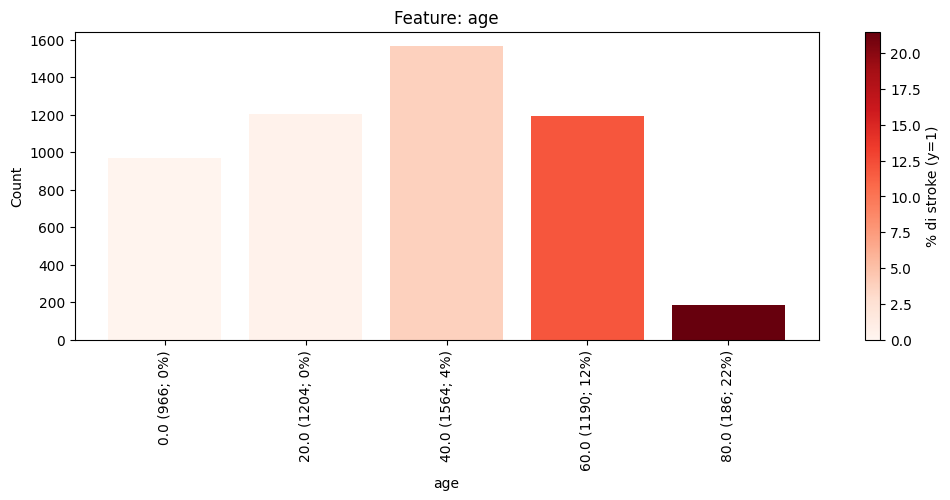

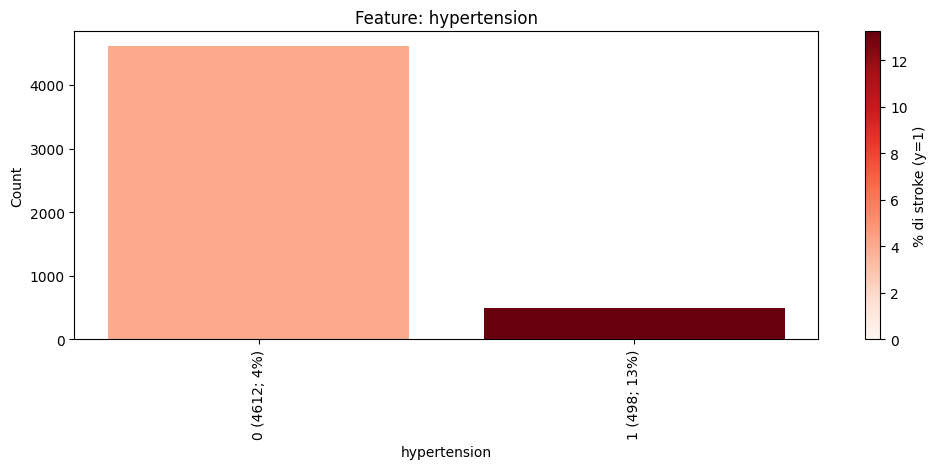

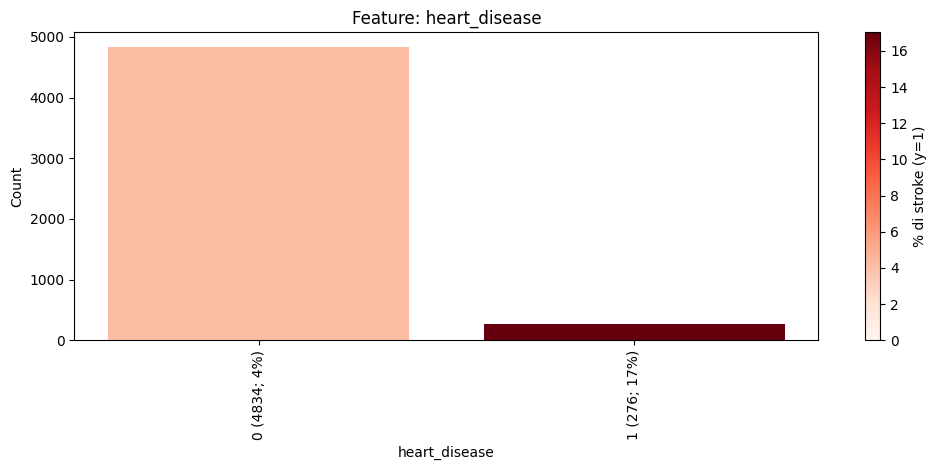

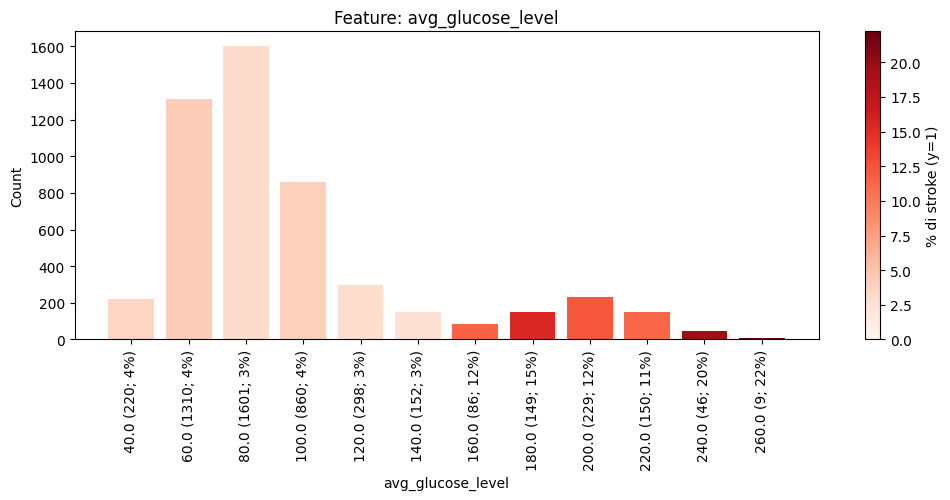

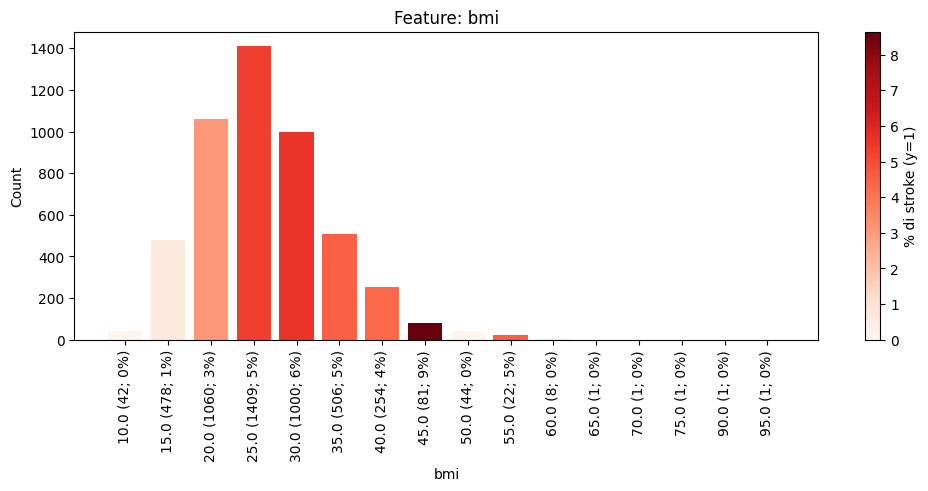

In [10]:
grouping = {
    'age': 20,
    'hypertension': 1,
    'heart_disease': 1,
    'avg_glucose_level': 20,
    'bmi': 5,
}
for feature in numerical_features:
    print_features_bar(X, feature, y, grouping=grouping[feature])

1. suddividere le età in 3 livelli di rischio:
* age_low_risk: boolean < 40
* age_mid_risk: boolean 40 - 60
* age_high_risk: boolean > 60

2. suddividere il livello di glucosio in 3 livelli di rischio:
* glucose_low_risk < 120
* glucose_mid_risk 120 - 220
* glucose_high_risk > 220

3. suddividere il bmi in 4 categorie:
* bmi_error:  < 15 o  >= 60
* bmi_low_risk: >= 15 e < 25
* bmi_mid_risk: >= 25 e < 40
* bmi_high_risk: >= 40 e <60

In [11]:
X['age_low_risk'] = X['age'] < 40
X['age_medium_risk'] = (X['age'] >= 40) & (X['age'] < 60)
X['age_high_risk'] = X['age'] >= 60
X.drop(columns=['age'], inplace=True)

In [12]:
X['glucose_low_risk'] = X['avg_glucose_level'] < 120
X['glucose_medium_risk'] = (X['avg_glucose_level'] >= 120) & (X['avg_glucose_level'] < 220)
X['glucose_high_risk'] = X['avg_glucose_level'] >= 220
X.drop(columns=['avg_glucose_level'], inplace=True)

In [13]:
X['bmi_error'] = (X['bmi'] < 15) | (X['bmi'] >= 60)
X['bmi_low_risk'] = (X['bmi'] >= 15) & (X['bmi'] < 25)
X['bmi_medium_risk'] = (X['bmi'] >= 25) & (X['bmi'] < 40)
X['bmi_high_risk'] = (X['bmi'] >= 40) & (X['bmi'] < 60)
X.drop(columns=['bmi'], inplace=True)

In [14]:
X

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_error,bmi_low_risk,bmi_medium_risk,bmi_high_risk
0,Male,0,1,Yes,Private,Urban,formerly smoked,False,False,True,False,False,True,False,False,True,False
1,Female,0,0,Yes,Self-employed,Rural,never smoked,False,False,True,False,True,False,False,False,False,False
2,Male,0,1,Yes,Private,Rural,never smoked,False,False,True,True,False,False,False,False,True,False
3,Female,0,0,Yes,Private,Urban,smokes,False,True,False,False,True,False,False,False,True,False
4,Female,1,0,Yes,Self-employed,Rural,never smoked,False,False,True,False,True,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,1,0,Yes,Private,Urban,never smoked,False,False,True,True,False,False,False,False,False,False
5106,Female,0,0,Yes,Self-employed,Urban,never smoked,False,False,True,False,True,False,False,False,False,True
5107,Female,0,0,Yes,Self-employed,Rural,never smoked,True,False,False,True,False,False,False,False,True,False
5108,Male,0,0,Yes,Private,Rural,formerly smoked,False,True,False,False,True,False,False,False,True,False


In [15]:
X.columns

Index(['gender', 'hypertension', 'heart_disease', 'ever_married', 'work_type',
       'Residence_type', 'smoking_status', 'age_low_risk', 'age_medium_risk',
       'age_high_risk', 'glucose_low_risk', 'glucose_medium_risk',
       'glucose_high_risk', 'bmi_error', 'bmi_low_risk', 'bmi_medium_risk',
       'bmi_high_risk'],
      dtype='object')

vediamo come vanno le cose per tutte le età

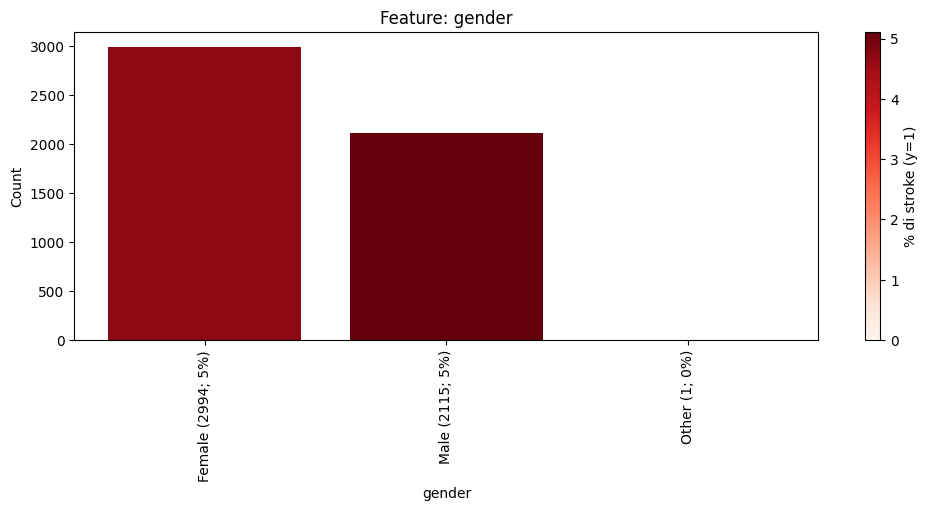

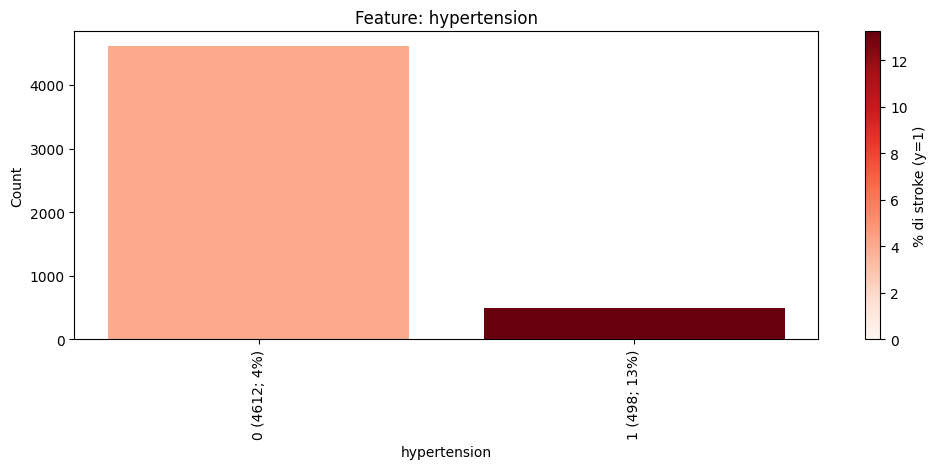

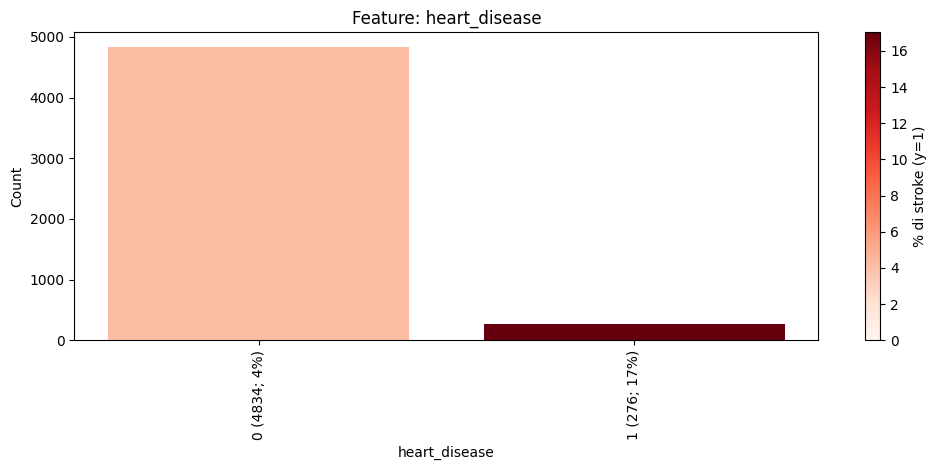

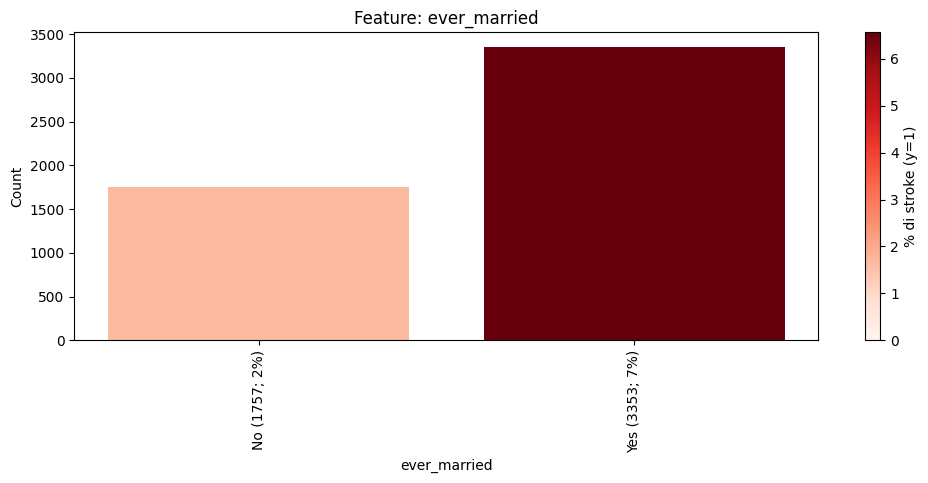

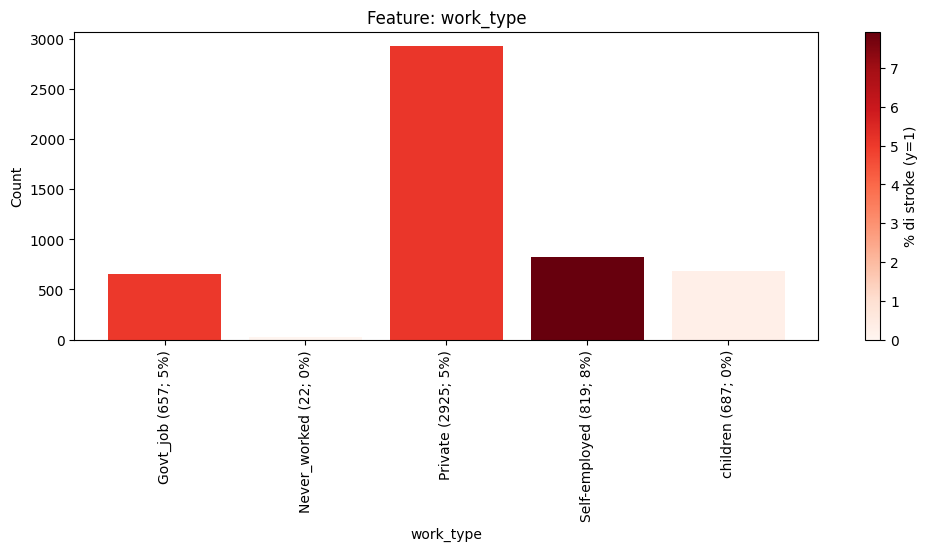

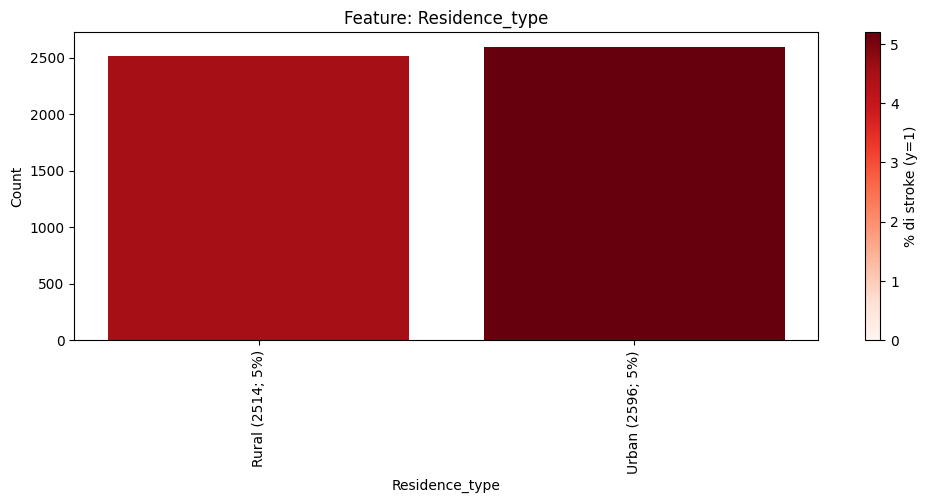

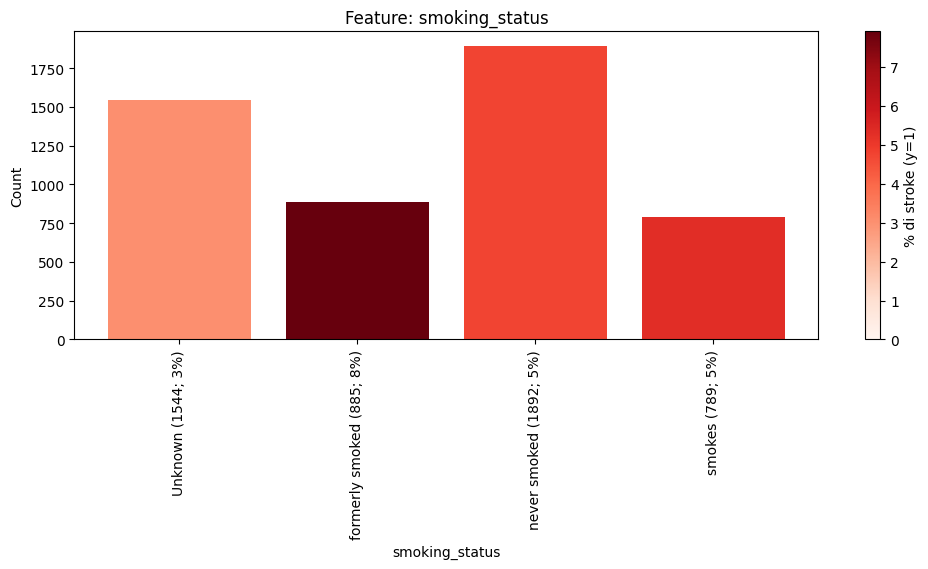

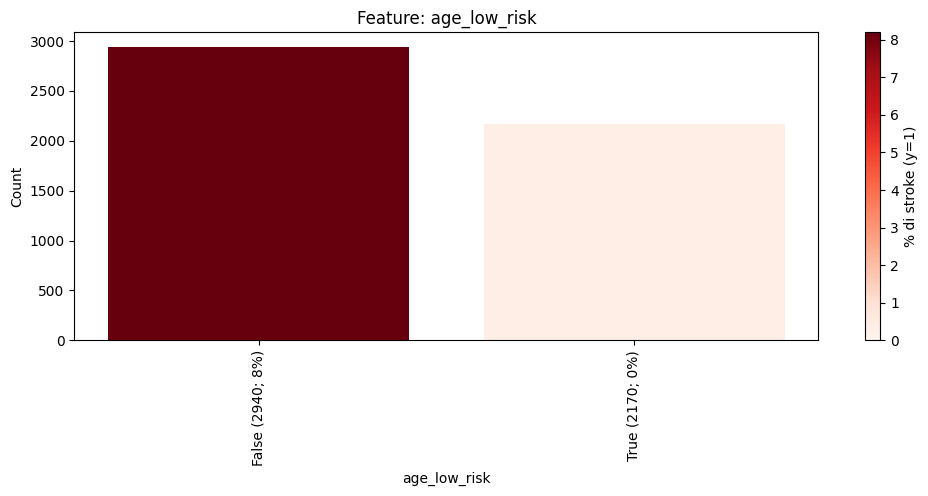

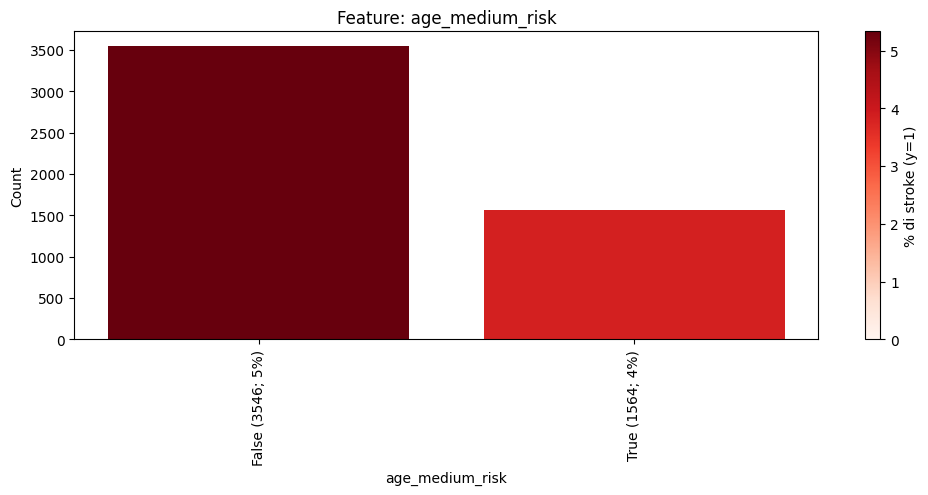

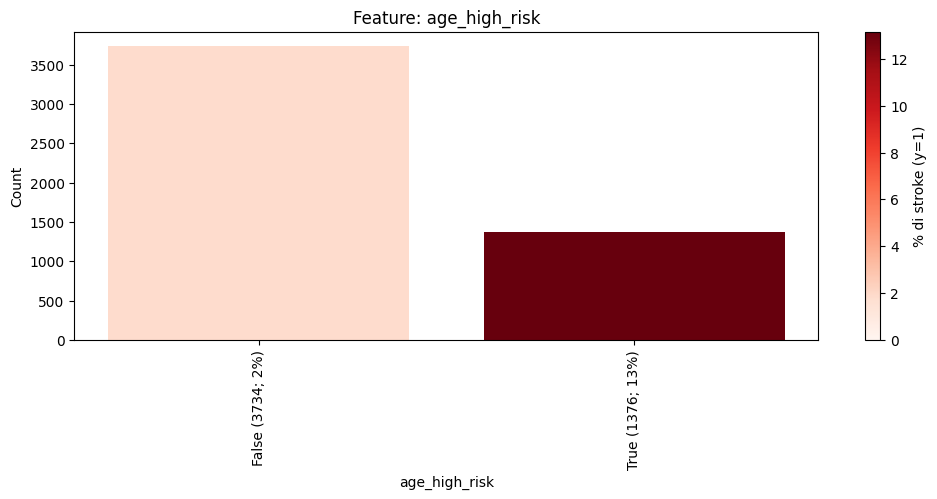

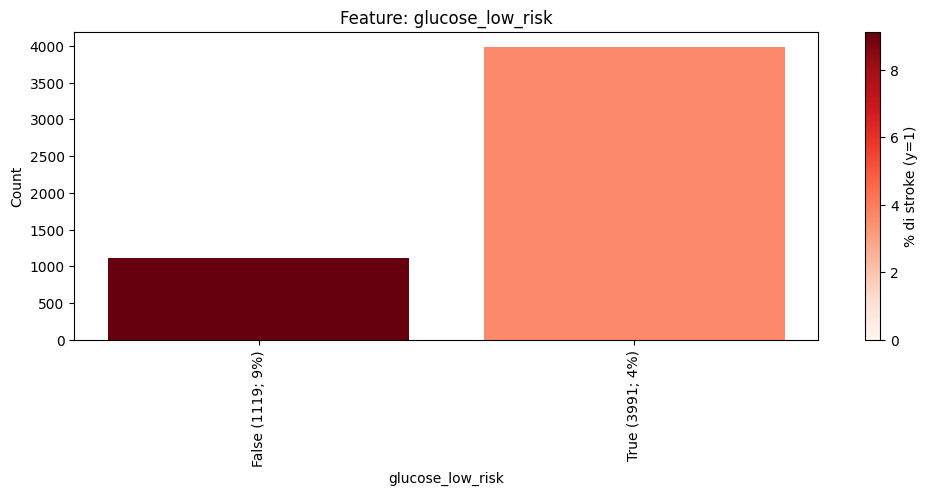

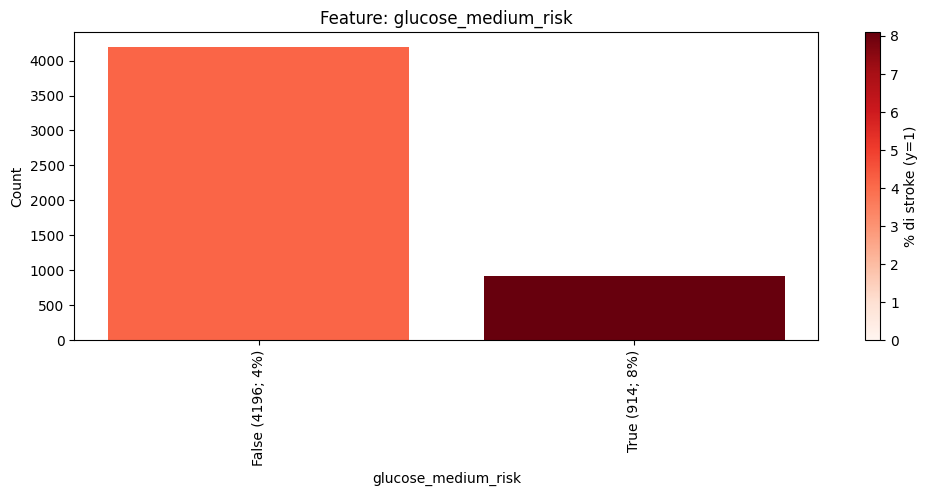

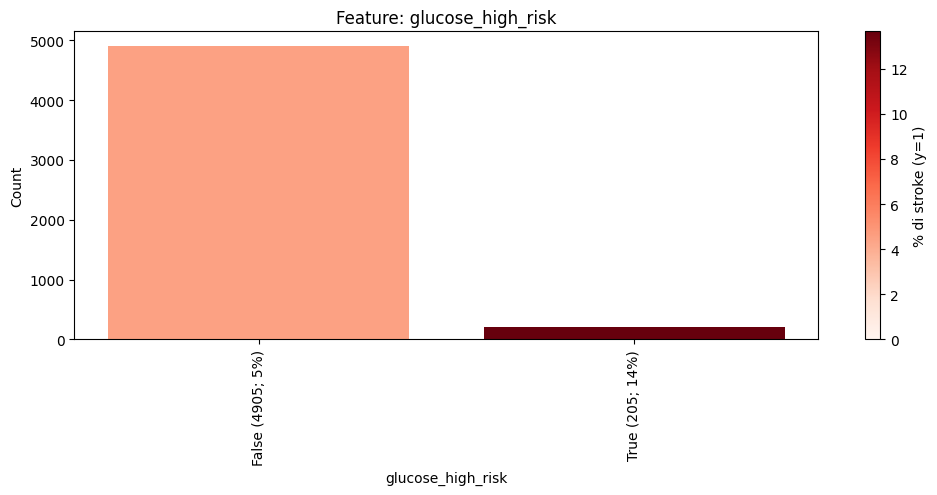

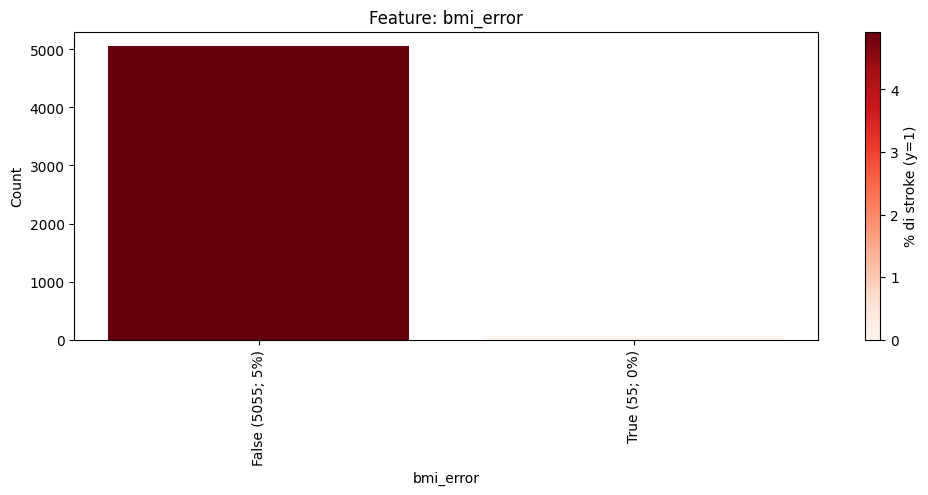

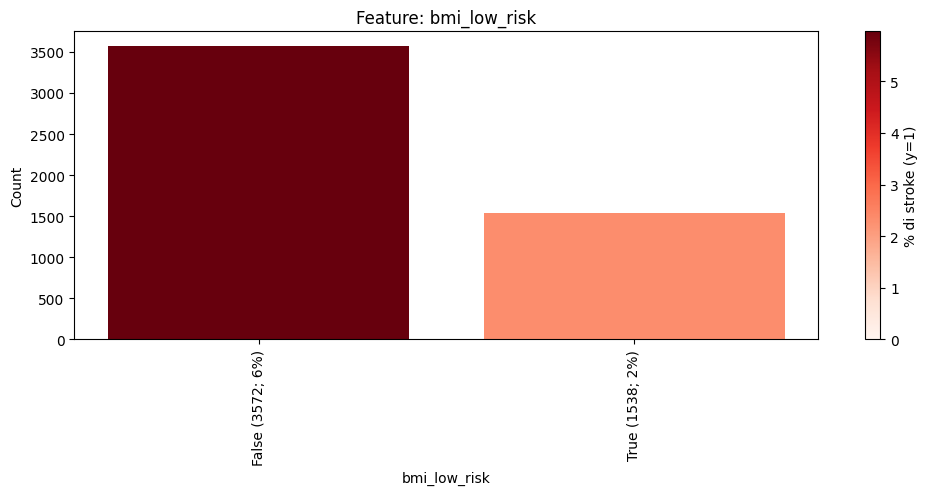

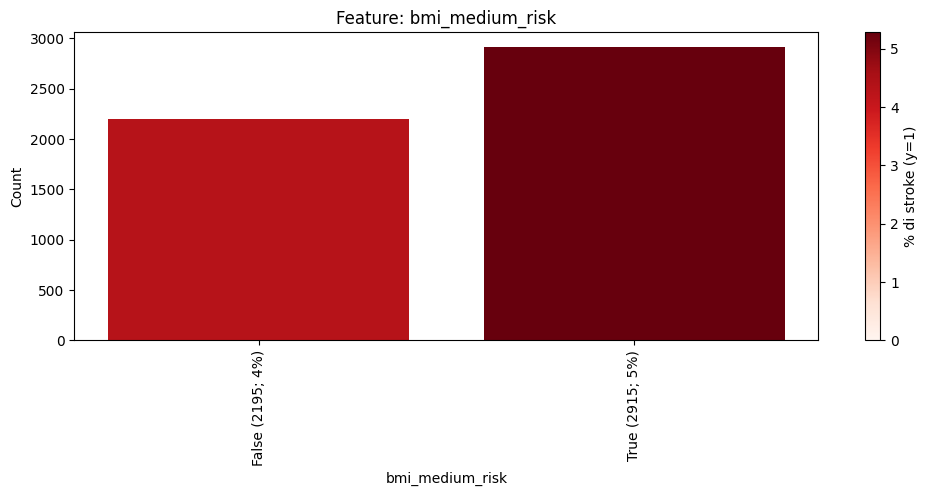

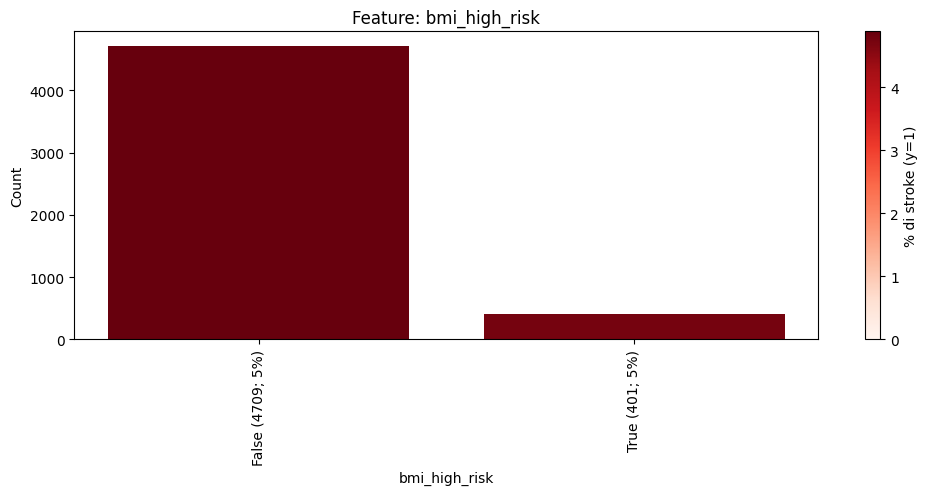

In [16]:
for col in X.columns:
  print_features_bar(X, col, y, type='categorical')

gender:
i maschi sembrano avere pari rischio delle femmine
esiste una persona di cui non è stato registrato il gender, questa non ha avuto uno stroke.
Potrebbe aver senso eliminarla

hypertension:
Il rischio sembra essere ampiamente superiore in chi soffre di ipertensione

heart_disease:
Il rischio sembra essere ampiamente superiore in chi soffre di problemi al cuore

ever_married:
il rischio sembra essere sensibilmente superiore in chi si è sposato, ma questo potrebbe risultare ingannevole visto che nessun bambino si è mai sposato, potrebbe essere oggetto di analisi al variare della fascia di età

work_type: il rischio sembra essere minore nei bambini e in chi non ha mai lavorato, maggiore per i self-employed, anche qui abbiamo bisogno di uno studio più preciso in base alla fascia di età

residence_type: il rischio sembra essere uguale sia per chi vive in campagna sia per chi vive in città

smoking_status: maggiori rischio sembrano esserci per chi ha fumato in passato ma poi ha smesso, questo però potrebbe dipendere dal fatto che molti anziani abbiano smesso di fumare

bmi_error: le persone a cui è stato sbagliato il bmi sembrano non aver registrato alcun ictus, forse, dato che occupano una percentuale bassa e si sta lavorando su un dataset estremamente sbilanciato potrebbe convenire toglierle

In [17]:
X.shape

(5110, 17)

In [18]:
no_bmi_error = X['bmi_error'] == False
X = X[no_bmi_error]
y = y[no_bmi_error]

In [19]:
X.shape

(5055, 17)

In [20]:
no_other_gender = X['gender'] != 'Other'
X = X[no_other_gender]
y = y[no_other_gender]

In [21]:
X.shape

(5054, 17)

In [22]:
X.drop(columns=['bmi_error'], inplace=True)

In [23]:
X

,gender,hypertension,heart_disease,ever_married,work_type,Residence_type,smoking_status,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_low_risk,bmi_medium_risk,bmi_high_risk
0,Male,0,1,Yes,Private,Urban,formerly smoked,False,False,True,False,False,True,False,True,False
1,Female,0,0,Yes,Self-employed,Rural,never smoked,False,False,True,False,True,False,False,False,False
2,Male,0,1,Yes,Private,Rural,never smoked,False,False,True,True,False,False,False,True,False
3,Female,0,0,Yes,Private,Urban,smokes,False,True,False,False,True,False,False,True,False
4,Female,1,0,Yes,Self-employed,Rural,never smoked,False,False,True,False,True,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,Female,1,0,Yes,Private,Urban,never smoked,False,False,True,True,False,False,False,False,False
5106,Female,0,0,Yes,Self-employed,Urban,never smoked,False,False,True,False,True,False,False,False,True
5107,Female,0,0,Yes,Self-employed,Rural,never smoked,True,False,False,True,False,False,False,True,False
5108,Male,0,0,Yes,Private,Rural,formerly smoked,False,True,False,False,True,False,False,True,False


In [24]:
X['male'] = X['gender'] == 'Male'
X.drop(columns=['gender'], inplace=True)

In [25]:
X['work_type'].unique()

array(['Private', 'Self-employed', 'Govt_job', 'children', 'Never_worked'],
      dtype=object)

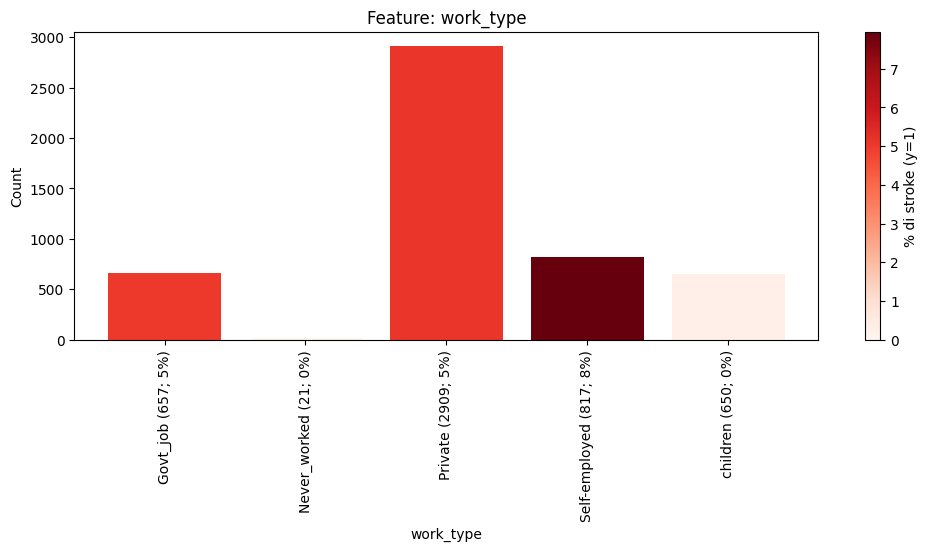

In [26]:
print_features_bar(X, 'work_type', y, type='categorical')

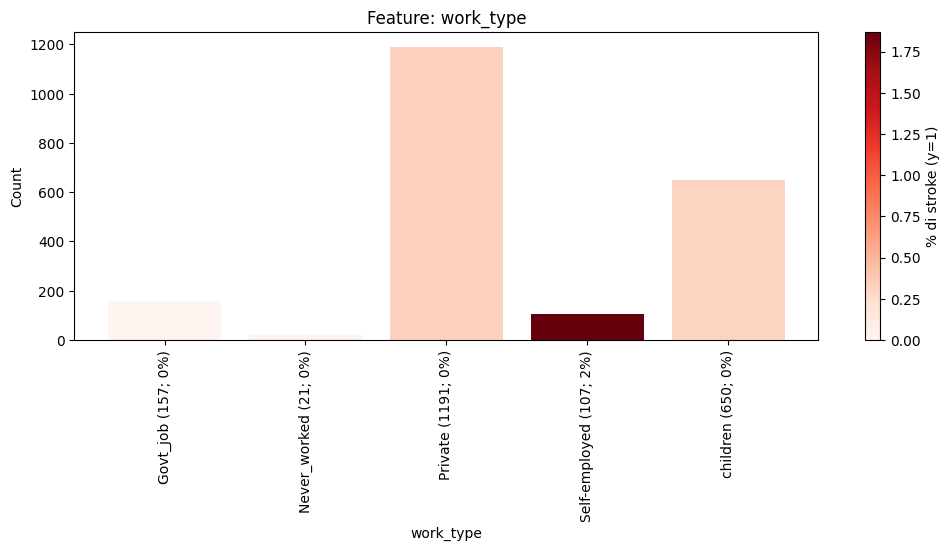

In [ ]:
# filtro solo le età a basso rischio
print_features_bar(X[X['age_low_risk']], 'work_type', y[X['age_low_risk']], type='categorical')

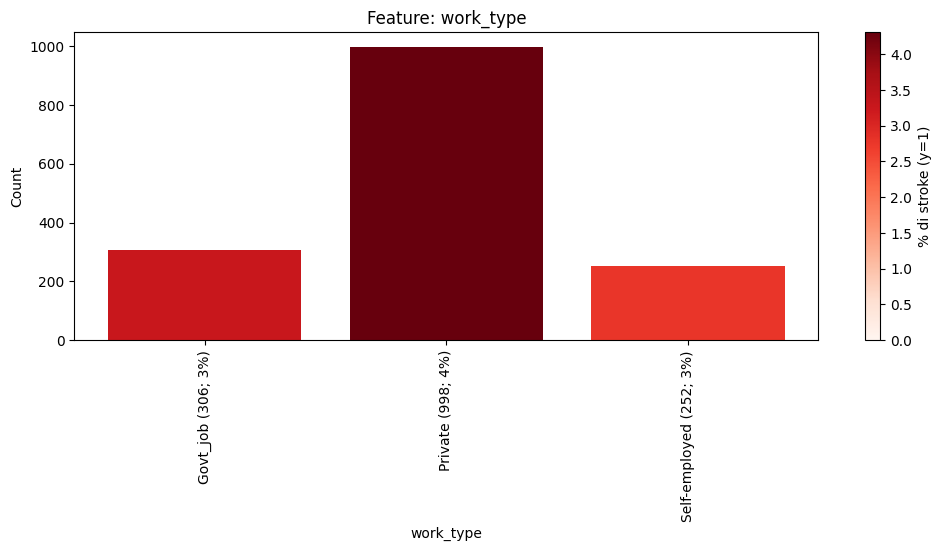

In [31]:
# filtro solo le età a medio rischio
print_features_bar(X[X['age_medium_risk']], 'work_type', y[X['age_medium_risk']], type='categorical')

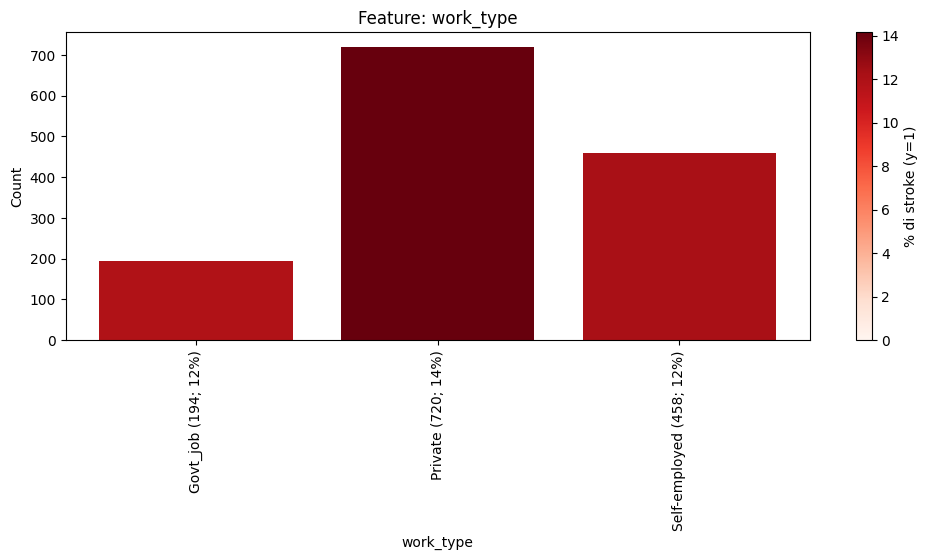

In [32]:
# filtro solo le età ad alto rischio
print_features_bar(X[X['age_high_risk']], 'work_type', y[X['age_high_risk']], type='categorical')

mentre nelle età a basso rischio (fino ai 40 anni) il rischio di ipertensione è molto alto tra i lavoratori autonomi, risulta evidente che il rischio nelle persone ad età avanzata è maggiore tra i privati mentre i lavoratori automi restano con un rischio allineato a quello deli lavoratori governativi

ora passo a separare il tipo di lavoratore, mentre chi non ha mai lavorato e i bambini (che non hanno mai lavorato) sembrano presentare un rischio pressochè nullo.

Ora andrò a creare 4 features (work_governative, work_private, work_self, work_never) portando i children dentro a work_never

In [33]:
X['work_governative'] = X['work_type'] == 'Govt_job'
X['work_private'] = X['work_type'] == 'Private'
X['work_self'] = X['work_type'] == 'Self-employed'
X['work_never'] = X['work_type'].isin(['children', 'Never_worked'])

X.drop(columns=['work_type'], inplace=True)

In [34]:
X

,hypertension,heart_disease,ever_married,Residence_type,smoking_status,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_low_risk,bmi_medium_risk,bmi_high_risk,male,work_governative,work_private,work_self,work_never
0,0,1,Yes,Urban,formerly smoked,False,False,True,False,False,True,False,True,False,True,False,True,False,False
1,0,0,Yes,Rural,never smoked,False,False,True,False,True,False,False,False,False,False,False,False,True,False
2,0,1,Yes,Rural,never smoked,False,False,True,True,False,False,False,True,False,True,False,True,False,False
3,0,0,Yes,Urban,smokes,False,True,False,False,True,False,False,True,False,False,False,True,False,False
4,1,0,Yes,Rural,never smoked,False,False,True,False,True,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,0,Yes,Urban,never smoked,False,False,True,True,False,False,False,False,False,False,False,True,False,False
5106,0,0,Yes,Urban,never smoked,False,False,True,False,True,False,False,False,True,False,False,False,True,False
5107,0,0,Yes,Rural,never smoked,True,False,False,True,False,False,False,True,False,False,False,False,True,False
5108,0,0,Yes,Rural,formerly smoked,False,True,False,False,True,False,False,True,False,True,False,True,False,False


all ages


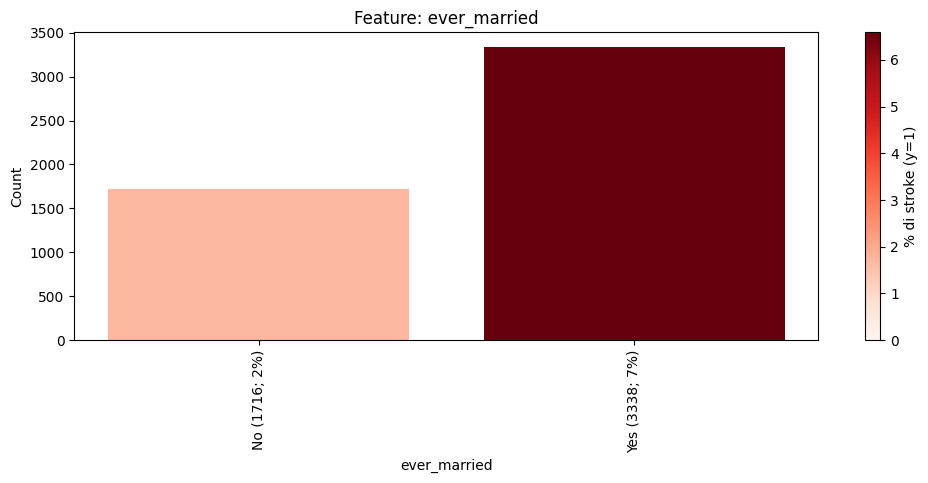

low risk ages


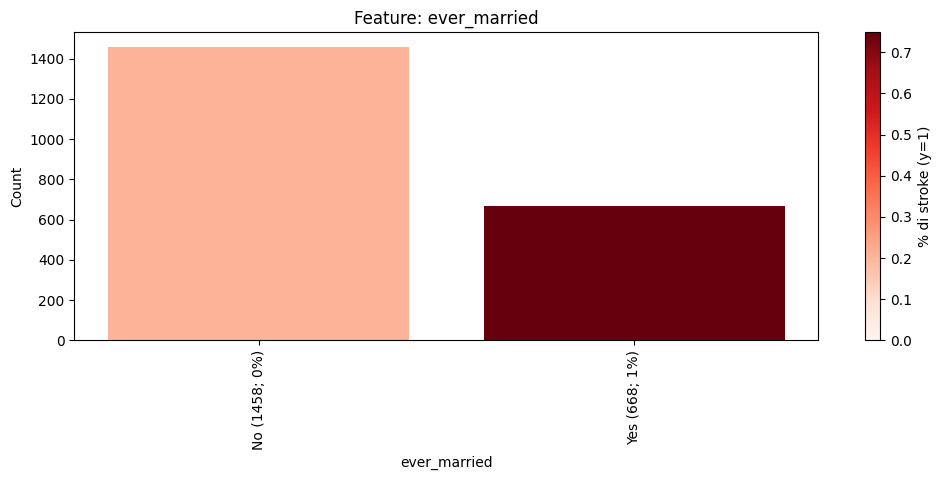

medium risk ages


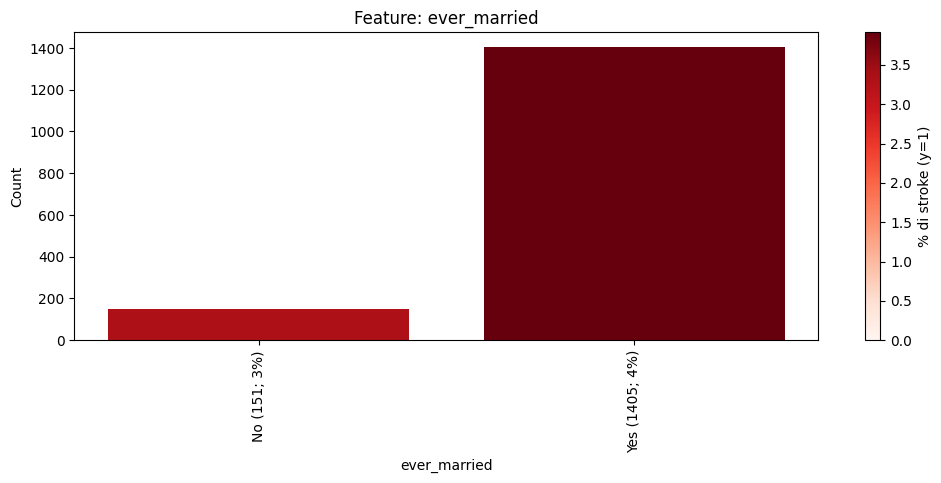

high risk ages


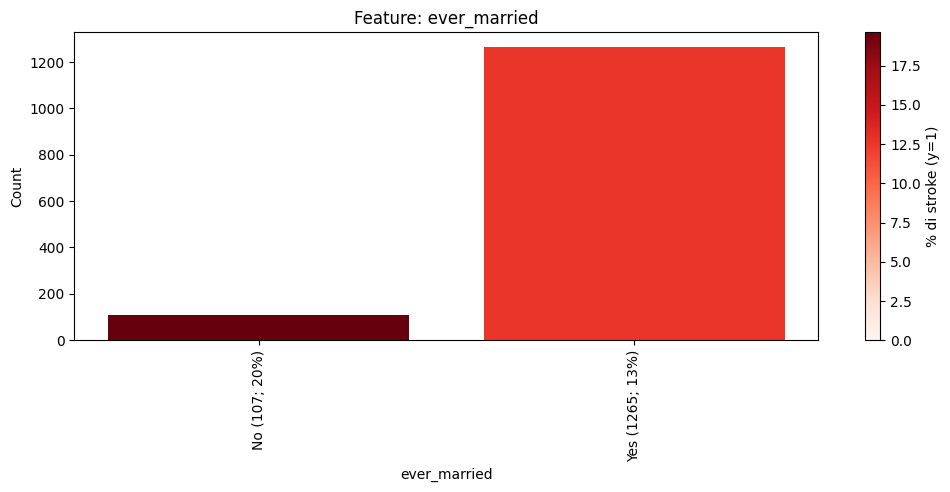

In [36]:
print('all ages')
print_features_bar(X, 'ever_married', y, type='categorical')
print('low risk ages')
print_features_bar(X[X['age_low_risk']], 'ever_married', y[X['age_low_risk']], type='categorical')
print('medium risk ages')
print_features_bar(X[X['age_medium_risk']], 'ever_married', y[X['age_medium_risk']], type='categorical')
print('high risk ages')
print_features_bar(X[X['age_high_risk']], 'ever_married', y[X['age_high_risk']], type='categorical')

Per quanto non filtrando in base all'età possa sembrare che chi è sposato abbia maggiori probabilità di avere lo stroke possiamo vedere che nell'età in cui il rischio è più significativo il rischio di ictus sia maggiore per chi non è sposato, questi dati apparentemente paradossali possono essere spiegato dal fatto che sotto i 16 anni nessuno si sposa, mentre andando a filtrare per età si rimuovono quei casi e quando si diventa anziani lo stile di vita (che chi è sposato probabilmente ha migliore) influisce sul rischio di ictus

In [37]:
X['ever_married'] = X['ever_married'] == 'Yes'

In [38]:
X

,hypertension,heart_disease,ever_married,Residence_type,smoking_status,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_low_risk,bmi_medium_risk,bmi_high_risk,male,work_governative,work_private,work_self,work_never
0,0,1,True,Urban,formerly smoked,False,False,True,False,False,True,False,True,False,True,False,True,False,False
1,0,0,True,Rural,never smoked,False,False,True,False,True,False,False,False,False,False,False,False,True,False
2,0,1,True,Rural,never smoked,False,False,True,True,False,False,False,True,False,True,False,True,False,False
3,0,0,True,Urban,smokes,False,True,False,False,True,False,False,True,False,False,False,True,False,False
4,1,0,True,Rural,never smoked,False,False,True,False,True,False,True,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,0,True,Urban,never smoked,False,False,True,True,False,False,False,False,False,False,False,True,False,False
5106,0,0,True,Urban,never smoked,False,False,True,False,True,False,False,False,True,False,False,False,True,False
5107,0,0,True,Rural,never smoked,True,False,False,True,False,False,False,True,False,False,False,False,True,False
5108,0,0,True,Rural,formerly smoked,False,True,False,False,True,False,False,True,False,True,False,True,False,False


all ages


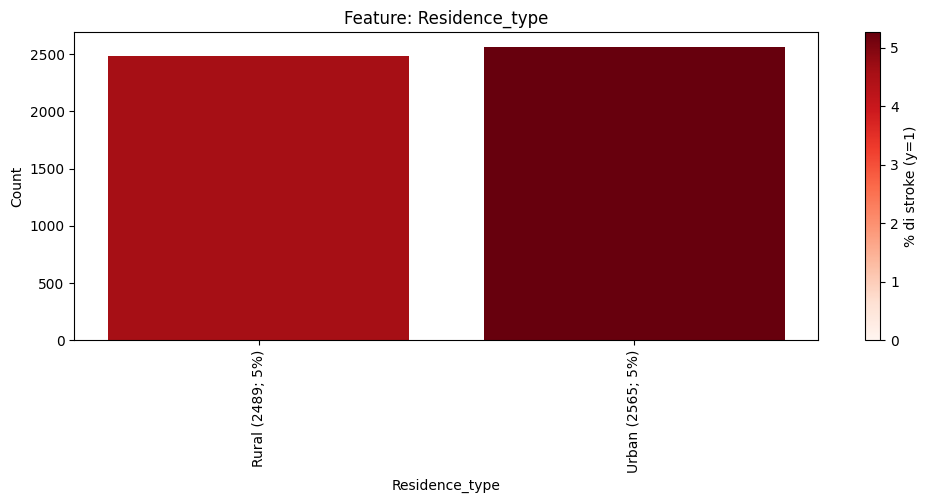

low risk ages


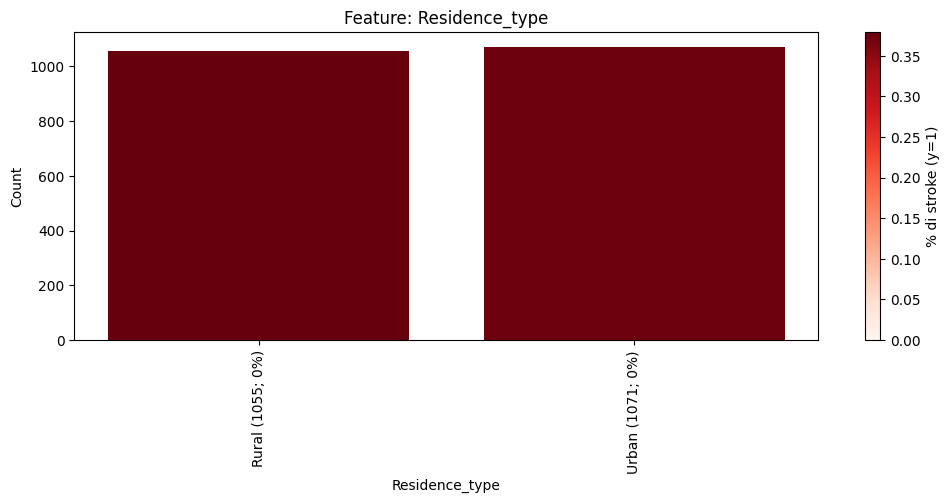

medium risk ages


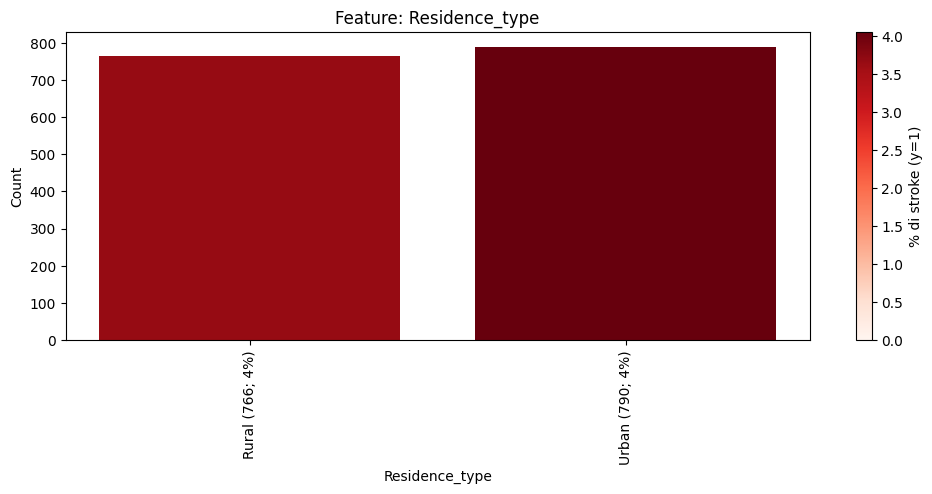

high risk ages


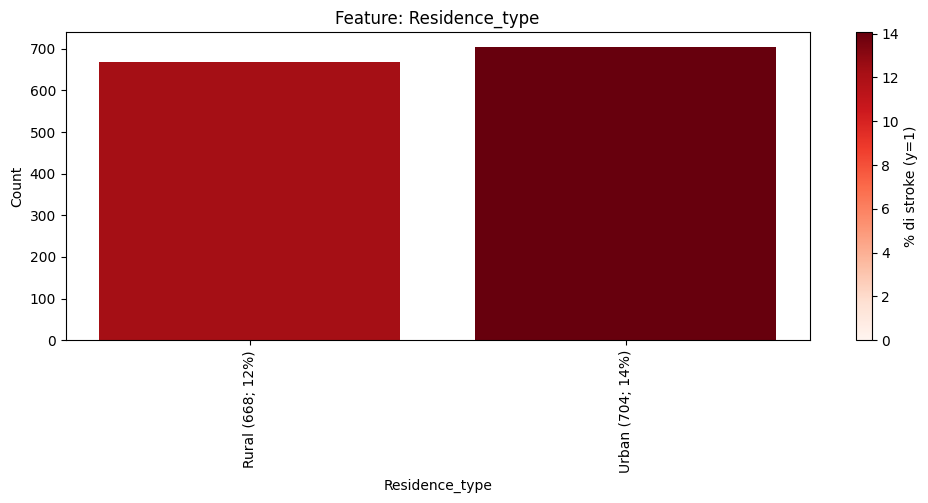

In [39]:
print('all ages')
print_features_bar(X, 'Residence_type', y, type='categorical')
print('low risk ages')
print_features_bar(X[X['age_low_risk']], 'Residence_type', y[X['age_low_risk']], type='categorical')
print('medium risk ages')
print_features_bar(X[X['age_medium_risk']], 'Residence_type', y[X['age_medium_risk']], type='categorical')
print('high risk ages')
print_features_bar(X[X['age_high_risk']], 'Residence_type', y[X['age_high_risk']], type='categorical')

Il tipo di residenza influisce sul rischio di ictus soprattutto oltre i 60 anni, da qui emerge che chi ha più di 60 anni ha un maggiore rischio di ictus se vive in città

In [40]:
X['Residence_type_Urban'] = X['Residence_type'] == 'Urban'

X.drop(columns=['Residence_type'], inplace=True)

In [41]:
X

,hypertension,heart_disease,ever_married,smoking_status,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_low_risk,bmi_medium_risk,bmi_high_risk,male,work_governative,work_private,work_self,work_never,Residence_type_Urban
0,0,1,True,formerly smoked,False,False,True,False,False,True,False,True,False,True,False,True,False,False,True
1,0,0,True,never smoked,False,False,True,False,True,False,False,False,False,False,False,False,True,False,False
2,0,1,True,never smoked,False,False,True,True,False,False,False,True,False,True,False,True,False,False,False
3,0,0,True,smokes,False,True,False,False,True,False,False,True,False,False,False,True,False,False,True
4,1,0,True,never smoked,False,False,True,False,True,False,True,False,False,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,0,True,never smoked,False,False,True,True,False,False,False,False,False,False,False,True,False,False,True
5106,0,0,True,never smoked,False,False,True,False,True,False,False,False,True,False,False,False,True,False,True
5107,0,0,True,never smoked,True,False,False,True,False,False,False,True,False,False,False,False,True,False,False
5108,0,0,True,formerly smoked,False,True,False,False,True,False,False,True,False,True,False,True,False,False,False


all ages


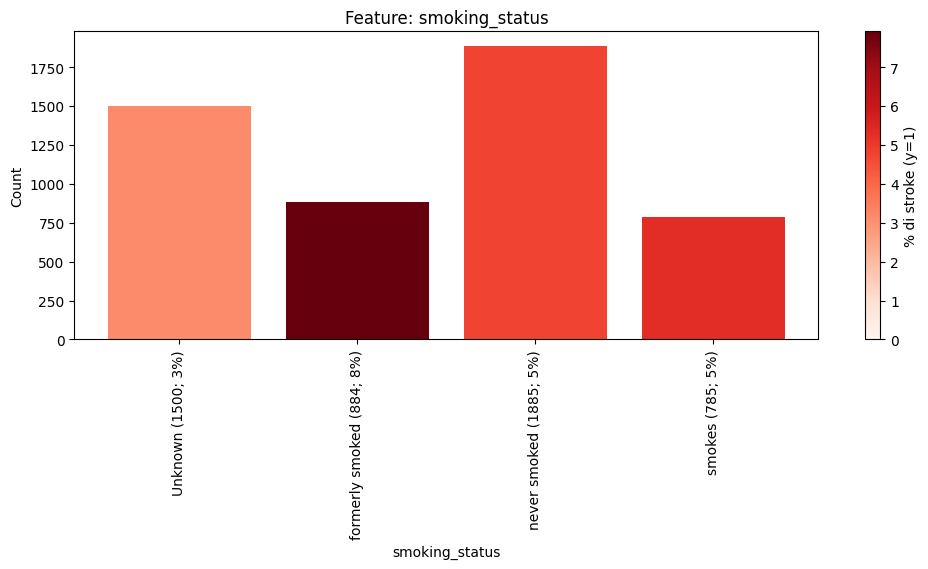

low risk ages


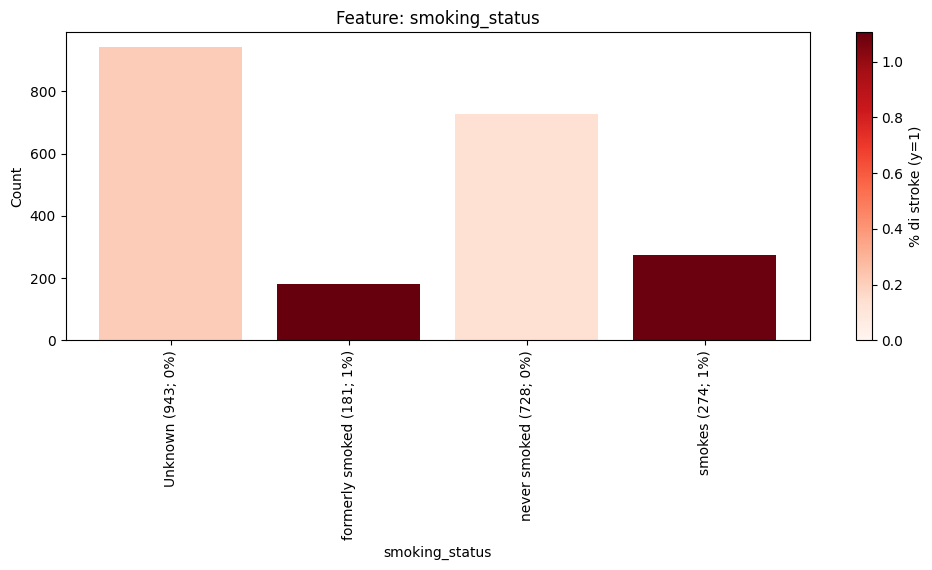

medium risk ages


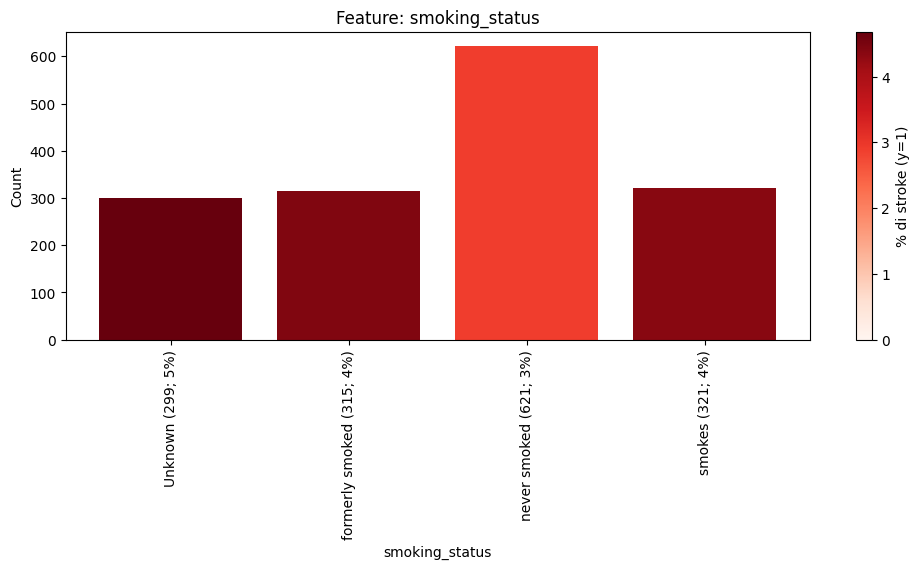

high risk ages


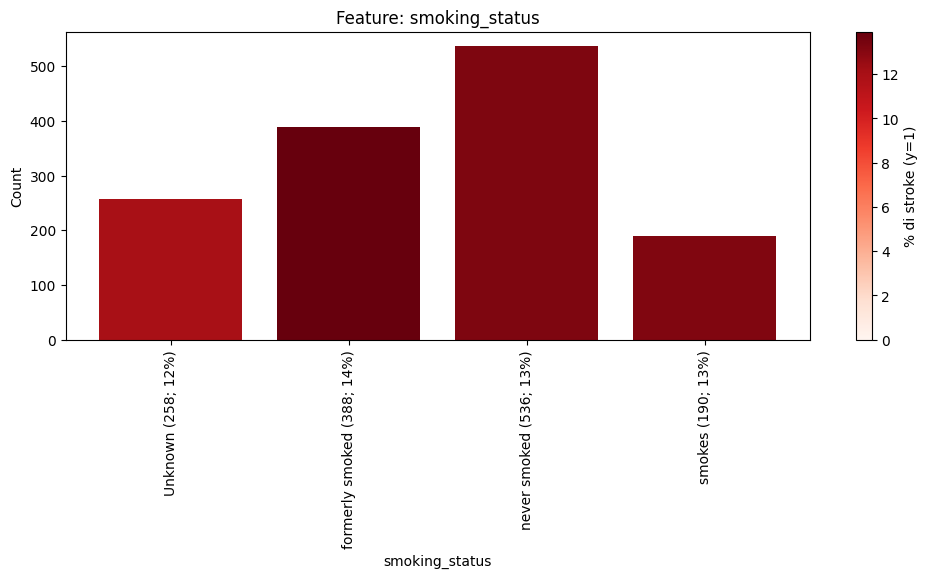

In [42]:
print('all ages')
print_features_bar(X, 'smoking_status', y, type='categorical')
print('low risk ages')
print_features_bar(X[X['age_low_risk']], 'smoking_status', y[X['age_low_risk']], type='categorical')
print('medium risk ages')
print_features_bar(X[X['age_medium_risk']], 'smoking_status', y[X['age_medium_risk']], type='categorical')
print('high risk ages')
print_features_bar(X[X['age_high_risk']], 'smoking_status', y[X['age_high_risk']], type='categorical')

il rischio di ictus tra i fumatori:

da questi dati emerge che i coloro che non hanno mai fumato sono a basso rischio entro i 40 e a minor rischio rispetto a fumatori e fumatori in passato fino a 60 anni.
Passati i 60 il rischio di ictus tra chi non ha mai fumato e chi sta fumando ora sembra eguagliarsi ma quello tra i fumatori precedenti sembra essere maggiore.

Questo potrebbe essere spiegato in quanto i fumatori più forti potrebbero aver avuto gravi problemi di salute che li hanno portati a smettere di fumare o hanno avuto ictus entro i 60 anni.

Ci sono invece alcuni di cui non sappiamo se siano mai stati fumatori.

Questi tendono ad vere una percentuale particolarmente bassa di ictus tranne nell'età di rischio medio in cui questa è leggermente più alta.

Potrebbero essere nella maggior parte dei casi non fumatori che non sono stati censiti, il fatto che la percentuale sia stata più alta nell'età a metà rischio invece potrebbe indicare che li ci siano stati fumatori o ex-fumatori o potrebbe essere un caso.
In questo caso direi di utlizzare tutte e 4 le features

In [43]:
X['smoking_status'].unique()

array(['formerly smoked', 'never smoked', 'smokes', 'Unknown'],
      dtype=object)

In [44]:
X['smoking_status_former'] = X['smoking_status'] == 'formerly smoked'
X['smoking_status_never'] = X['smoking_status'] == 'never smoked'
X['smoking_status_smokes'] = X['smoking_status'] == 'smokes'
X['smoking_status_unknown'] = X['smoking_status'] == 'Unknown'
X.drop(columns=['smoking_status'], inplace=True)

In [45]:
X

,hypertension,heart_disease,ever_married,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_low_risk,...,male,work_governative,work_private,work_self,work_never,Residence_type_Urban,smoking_status_former,smoking_status_never,smoking_status_smokes,smoking_status_unknown
0,0,1,True,False,False,True,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
1,0,0,True,False,False,True,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
2,0,1,True,False,False,True,True,False,False,False,...,True,False,True,False,False,False,False,True,False,False
3,0,0,True,False,True,False,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
4,1,0,True,False,False,True,False,True,False,True,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,1,0,True,False,False,True,True,False,False,False,...,False,False,True,False,False,True,False,True,False,False
5106,0,0,True,False,False,True,False,True,False,False,...,False,False,False,True,False,True,False,True,False,False
5107,0,0,True,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
5108,0,0,True,False,True,False,False,True,False,False,...,True,False,True,False,False,False,True,False,False,False


In [46]:
X['hypertension'] = X['hypertension'] == 1
X['heart_disease'] = X['heart_disease'] == 1

In [47]:
X

,hypertension,heart_disease,ever_married,age_low_risk,age_medium_risk,age_high_risk,glucose_low_risk,glucose_medium_risk,glucose_high_risk,bmi_low_risk,...,male,work_governative,work_private,work_self,work_never,Residence_type_Urban,smoking_status_former,smoking_status_never,smoking_status_smokes,smoking_status_unknown
0,False,True,True,False,False,True,False,False,True,False,...,True,False,True,False,False,True,True,False,False,False
1,False,False,True,False,False,True,False,True,False,False,...,False,False,False,True,False,False,False,True,False,False
2,False,True,True,False,False,True,True,False,False,False,...,True,False,True,False,False,False,False,True,False,False
3,False,False,True,False,True,False,False,True,False,False,...,False,False,True,False,False,True,False,False,True,False
4,True,False,True,False,False,True,False,True,False,True,...,False,False,False,True,False,False,False,True,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5105,True,False,True,False,False,True,True,False,False,False,...,False,False,True,False,False,True,False,True,False,False
5106,False,False,True,False,False,True,False,True,False,False,...,False,False,False,True,False,True,False,True,False,False
5107,False,False,True,True,False,False,True,False,False,False,...,False,False,False,True,False,False,False,True,False,False
5108,False,False,True,False,True,False,False,True,False,False,...,True,False,True,False,False,False,True,False,False,False


ecco le 